In [1]:
# --- arranque en Colab (no hace nada fuera de Colab) -----------------------
# Colab arranca en /content con un entorno vacío: sin esta celda el
# `import environment` siguiente falla con ModuleNotFoundError. Generada por
# tools/py_to_notebook.py -- editala ahí, no acá.
import os
import subprocess
import sys

if "google.colab" in sys.modules:
    REPO_URL = "https://github.com/solidgoldmagickarp/proyecto_de_lenguaje_emergente.git"
    REPO_DIR = "proyecto_de_lenguaje_emergente"

    # El orden de las guardas importa: primero probar DÓNDE estamos, después qué hay en disco.
    # `isdir(REPO_DIR)` es relativo, así que chequearlo primero clonaría una copia
    # anidada en cualquier re-ejecución de esta celda dentro de la misma sesión (algo rutinario).
    if os.path.basename(os.getcwd()) != REPO_DIR:
        if not os.path.isdir(REPO_DIR):
            subprocess.run(["git", "clone", "--depth", "1", REPO_URL, REPO_DIR], check=True)
        os.chdir(REPO_DIR)
    if os.getcwd() not in sys.path:
        sys.path.insert(0, os.getcwd())

    subprocess.run(
        [sys.executable, "-m", "pip", "install", "-q", "-r", "requirements.txt"], check=True
    )

    # El disco de Colab es EFÍMERO: cada checkpoint se pierde cuando el entorno de ejecución
    # se desconecta (~90 min de inactividad en el plan gratuito), y las Etapas 3, 4 y 5 necesitan
    # todas los checkpoints de la Etapa 2. Descomentá para guardarlos en Drive en su lugar.
    #
    # Notar `islink`, no `exists`: importar `environment` crea un directorio checkpoints/
    # REAL, y `exists` entonces saltearía el enlace en silencio y mandaría cada
    # checkpoint de vuelta al disco efímero.
    #
    # from google.colab import drive
    # drive.mount("/content/drive")
    # PERSISTENT = "/content/drive/MyDrive/proyecto_de_lenguaje_emergente/checkpoints"
    # os.makedirs(PERSISTENT, exist_ok=True)
    # if os.path.islink("checkpoints"):
    #     print("checkpoints ->", os.readlink("checkpoints"))
    # elif os.path.isdir("checkpoints"):
    #     print("ADVERTENCIA: checkpoints/ ya es un directorio real, así que NO está en Drive.")
    #     print("Mové su contenido a", PERSISTENT, ", borralo, y volvé a ejecutar esta celda.")
    # else:
    #     os.symlink(PERSISTENT, "checkpoints")
    #     print("checkpoints ->", PERSISTENT)

    print("Arranque en Colab OK. Directorio de trabajo:", os.getcwd())

# Etapa 5 · Medir la emergencia — un juez local

Un número de perplejidad no dice *qué* mejoró. Acá un modelo local y gratuito (Ollama + `qwen3:4b`, sin
modo de razonamiento) le pone nota, como un docente corrigiendo a un alumno, a generaciones de:

- **base (ancho)** y **profundo**: las dos variantes de la ablación de la Etapa 2;
- **SFT completo** y **SFT LoRA**: los dos modelos de la Etapa 4 (LoRA, si se corrió).

Criterios, de 1 a 10: **gramática**, **creatividad**, **consistencia** y, para los prompts con instrucción,
**obediencia**. La obediencia también se le pide al base sobre los mismos prompts: es el control que dice
cuánto de "seguir la instrucción" ya estaba antes del SFT.

**Anclas para calibrar al juez** (nadie las pidió, pero sin ellas no se sabe si el juez discrimina):
cuentos **reales** de TinyStories (el techo esperable), los mismos cuentos con las **palabras mezcladas**
(misma temática y vocabulario, gramática destruida) y cuentos reales evaluados contra una **instrucción
ajena** (obediencia debería dar baja). Si el juez no separa esas tres cosas, sus notas sobre nuestros
modelos no valen mucho.

Después se cruza la lectura del juez con la **perplejidad** y con los prompts de prueba de la Etapa 2.

**Lee:** `checkpoints/tokenizer.json`, `pretrain_wide.pt`, `pretrain_deep.pt` (Etapa 2), `sft_final.pt`,
`sft_lora.pt` (Etapa 4; el de LoRA y el profundo son opcionales), y si existen `stage2_ablation.csv` y
`stage4/comparacion_lora.csv`. **Produce:** `checkpoints/stage5/` (notas, tablas, gráficos). Las respuestas
del juez se guardan a medida que llegan (`juez_respuestas.jsonl`): si Colab se corta, volver a correr
retoma sin repetir llamadas.

**Cómo correrlo.** En Colab con GPU: la celda del juez instala Ollama en la VM y baja `qwen3:4b` (~2,5 GB).
En CPU, `SMOKE_TEST` se activa solo y, si no hay Ollama, usa un **juez falso** que a propósito devuelve
respuestas mal formadas (dos objetos, texto alrededor, claves faltantes) para probar el parser. Sus notas
no significan nada.

In [2]:
import environment  # noqa: F401  (primero siempre: caché de HF, stdout UTF-8, checkpoints/)

environment.summary()

import hashlib
import json
import math
import os
import random
import re
import shutil
import subprocess
import sys
import time
from dataclasses import asdict, dataclass

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from tokenizers import Tokenizer
from torch.nn import functional as F

from data import load_tinystories

DEVICE = environment.device()
SMOKE_TEST = environment.smoke_test(DEVICE == "cpu")  # CPU: validar el pipeline. GPU: la corrida de verdad. LAB_SMOKE_TEST fuerza.
SEED = 1337

CKPT_DIR = environment.CHECKPOINTS / "smoke" if SMOKE_TEST else environment.CHECKPOINTS
TOKENIZER_PATH = environment.CHECKPOINTS / "tokenizer.json"
OUTPUT_DIR = CKPT_DIR / "stage5"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# Nombre legible -> checkpoint. Los obligatorios son los que pide la consigna como mínimo (Etapas 2 y 4).
MODEL_PATHS = {
    "base (ancho)": CKPT_DIR / "pretrain_wide.pt",
    "profundo": CKPT_DIR / "pretrain_deep.pt",
    "SFT completo": CKPT_DIR / "sft_final.pt",
    "SFT LoRA": CKPT_DIR / "sft_lora.pt",
}
REQUIRED = {"base (ancho)", "SFT completo"}

JUDGE_MODEL = "qwen3:4b"
USE_AMP = DEVICE == "cuda"

torch.manual_seed(SEED)
print(f"dispositivo: {DEVICE} · SMOKE_TEST: {SMOKE_TEST} · checkpoints en: {CKPT_DIR}")

ENTORNO
os             : Linux 6.18.48-gentoo-lean
python         : 3.14.7
venv           : /home/lucas/Proyecto1_IA_Generativa/.venv
cpu            : AMD Ryzen 9 8945HX with Radeon Graphics
logical_cores  : 32
torch          : 2.14.0+cu130
torch_threads  : 16
cuda_available : True
gpu            : NVIDIA GeForce RTX 5070 Laptop GPU
gpu_memory_gb  : 8.08
ram_total_gb   : 32.9
ram_free_gb    : 30.2
--------------------------------------------------------------
HF_HOME        : /home/lucas/Proyecto1_IA_Generativa/.hf_cache
ca_bundle      : no presente (normal)


dispositivo: cuda · SMOKE_TEST: False · checkpoints en: /home/lucas/Proyecto1_IA_Generativa/checkpoints


## Los modelos

Mismas clases que en las Etapas 2 y 4 (copia textual: importar esos archivos los ejecutaría enteros). El de
LoRA se guardó ya fusionado en la Etapa 4, así que se carga igual que los demás.

In [3]:
@dataclass
class GPTConfig:
    """Todo lo que define la FORMA del modelo. Va en cada checkpoint para reconstruirlo sin adivinar."""

    vocab_size: int
    block_size: int
    n_embd: int
    n_head: int
    n_layer: int
    dropout: float = 0.1


class Head(nn.Module):
    """Una cabeza de self-attention causal."""

    def __init__(self, cfg: GPTConfig, head_size: int):
        super().__init__()
        self.key = nn.Linear(cfg.n_embd, head_size, bias=False)
        self.query = nn.Linear(cfg.n_embd, head_size, bias=False)
        self.value = nn.Linear(cfg.n_embd, head_size, bias=False)
        self.register_buffer("tril", torch.tril(torch.ones(cfg.block_size, cfg.block_size)), persistent=False)
        self.dropout = nn.Dropout(cfg.dropout)

    def forward(self, x):
        B, T, C = x.shape
        k, q = self.key(x), self.query(x)  # (B, T, hs)
        wei = q @ k.transpose(-2, -1) * k.shape[-1] ** -0.5  # (B, T, T)
        wei = wei.masked_fill(self.tril[:T, :T] == 0, float("-inf"))
        wei = self.dropout(F.softmax(wei, dim=-1))
        return wei @ self.value(x)  # (B, T, hs)


class MultiHeadAttention(nn.Module):
    """Varias cabezas en paralelo; sus salidas se concatenan y se proyectan de vuelta a n_embd."""

    def __init__(self, cfg: GPTConfig):
        super().__init__()
        head_size = cfg.n_embd // cfg.n_head
        self.heads = nn.ModuleList(Head(cfg, head_size) for _ in range(cfg.n_head))
        self.proj = nn.Linear(cfg.n_embd, cfg.n_embd)
        self.dropout = nn.Dropout(cfg.dropout)

    def forward(self, x):
        out = torch.cat([h(x) for h in self.heads], dim=-1)
        return self.dropout(self.proj(out))


class FeedForward(nn.Module):
    """MLP por posición: expande a 4·n_embd, no linealidad, vuelve a n_embd."""

    def __init__(self, cfg: GPTConfig):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(cfg.n_embd, 4 * cfg.n_embd),
            nn.ReLU(),
            nn.Linear(4 * cfg.n_embd, cfg.n_embd),
            nn.Dropout(cfg.dropout),
        )

    def forward(self, x):
        return self.net(x)


class Block(nn.Module):
    """Comunicación (atención) y después cómputo (MLP), con pre-LayerNorm y conexiones residuales."""

    def __init__(self, cfg: GPTConfig):
        super().__init__()
        self.sa = MultiHeadAttention(cfg)
        self.ffwd = FeedForward(cfg)
        self.ln1 = nn.LayerNorm(cfg.n_embd)
        self.ln2 = nn.LayerNorm(cfg.n_embd)

    def forward(self, x):
        x = x + self.sa(self.ln1(x))
        return x + self.ffwd(self.ln2(x))


class GPTLanguageModel(nn.Module):
    def __init__(self, cfg: GPTConfig):
        super().__init__()
        assert cfg.n_embd % cfg.n_head == 0, "n_embd tiene que ser múltiplo de n_head"
        self.cfg = cfg
        self.token_embedding_table = nn.Embedding(cfg.vocab_size, cfg.n_embd)
        self.position_embedding_table = nn.Embedding(cfg.block_size, cfg.n_embd)
        self.blocks = nn.Sequential(*[Block(cfg) for _ in range(cfg.n_layer)])
        self.ln_f = nn.LayerNorm(cfg.n_embd)
        self.lm_head = nn.Linear(cfg.n_embd, cfg.vocab_size)
        self.apply(self._init_weights)

    @staticmethod
    def _init_weights(module):
        if isinstance(module, (nn.Linear, nn.Embedding)):
            nn.init.normal_(module.weight, mean=0.0, std=0.02)
        if isinstance(module, nn.Linear) and module.bias is not None:
            nn.init.zeros_(module.bias)

    def forward(self, idx, targets=None):
        B, T = idx.shape
        pos = torch.arange(T, device=idx.device)
        x = self.token_embedding_table(idx) + self.position_embedding_table(pos)  # (B, T, n_embd)
        logits = self.lm_head(self.ln_f(self.blocks(x)))  # (B, T, V)
        if targets is None:
            return logits, None
        loss = F.cross_entropy(logits.view(B * T, -1).float(), targets.view(B * T))
        return logits, loss

    @torch.no_grad()
    def generate(self, idx, max_new_tokens, *, temperature=1.0, greedy=False, generator=None, stop_token=None):
        """Extiende `idx` (B, T) token a token. Con `greedy`, siempre el más probable; si no, muestrea."""
        for _ in range(max_new_tokens):
            logits, _ = self(idx[:, -self.cfg.block_size :])
            logits = logits[:, -1, :].float()
            if greedy:
                next_id = logits.argmax(dim=-1, keepdim=True)
            else:
                probs = F.softmax(logits / temperature, dim=-1)
                next_id = torch.multinomial(probs, num_samples=1, generator=generator)
            idx = torch.cat([idx, next_id], dim=1)
            if stop_token is not None and (next_id == stop_token).all():
                break
        return idx


def load_model(path, device=DEVICE):
    """Reconstruye un modelo a partir de un checkpoint. Devuelve (modelo en modo eval, checkpoint crudo)."""
    checkpoint = torch.load(path, map_location=device)
    model = GPTLanguageModel(GPTConfig(**checkpoint["model_config"])).to(device)
    model.load_state_dict(checkpoint["state_dict"])
    return model.eval(), checkpoint

In [4]:
if not TOKENIZER_PATH.is_file():
    raise FileNotFoundError(f"No está {TOKENIZER_PATH}. Corré primero la Etapa 1, o traé el archivo de Drive.")
missing = [f"{name}: {path}" for name, path in MODEL_PATHS.items() if name in REQUIRED and not path.is_file()]
if missing:
    raise FileNotFoundError("Faltan checkpoints obligatorios (Etapas 2 y 4):\n  " + "\n  ".join(missing))

tokenizer = Tokenizer.from_file(str(TOKENIZER_PATH))
VOCAB_SIZE = tokenizer.get_vocab_size()
EOT_ID = tokenizer.token_to_id("<|endoftext|>")
TOKENIZER_SHA1 = hashlib.sha1(TOKENIZER_PATH.read_bytes()).hexdigest()

models, checkpoints = {}, {}
for name, path in MODEL_PATHS.items():
    if not path.is_file():
        print(f"aviso: no está {path.name}; '{name}' queda afuera de la comparación.")
        continue
    models[name], checkpoints[name] = load_model(path)
    assert models[name].cfg.vocab_size == VOCAB_SIZE, f"{path.name} no es del vocabulario de {TOKENIZER_PATH.name}"
    # Checkpoints viejos sin huella se aceptan; uno con huella distinta es de otro tokenizer.
    if checkpoints[name].get("tokenizer_sha1", TOKENIZER_SHA1) != TOKENIZER_SHA1:
        raise ValueError(f"{path.name} se entrenó con otro tokenizer.json (¿se volvió a correr la Etapa 1?).")
    n_params = sum(p.numel() for p in models[name].parameters())
    print(f"{name:<14} {path.name:<18} paso {checkpoints[name]['step']:>6,} · {n_params / 1e6:.2f}M parámetros")

base (ancho)   pretrain_wide.pt   paso  5,000 · 5.85M parámetros


profundo       pretrain_deep.pt   paso  5,000 · 5.42M parámetros
SFT completo   sft_final.pt       paso  1,500 · 5.85M parámetros


SFT LoRA       sft_lora.pt        paso  1,500 · 5.85M parámetros


## Perplejidad de cada modelo, con la misma vara

La pérdida sobre el split `validation` de TinyStories liso, **igual para todos**: los mismos batches (misma
semilla), ventanas al azar como en la Etapa 2. Así la pérdida del SFT (entrenado en otro formato) y la de
los preentrenados se leen en la misma escala. Ojo: para los de SFT es texto *fuera* de su formato de
entrenamiento, así que una suba acá mide olvido, no calidad.

In [5]:
N_VAL_STORIES = 300 if SMOKE_TEST else 5_000
EVAL_BATCHES, EVAL_BATCH_SIZE = (5, 8) if SMOKE_TEST else (40, 64)

val_texts = list(load_tinystories("validation", limit=N_VAL_STORIES)["text"])
val_ids = np.concatenate([np.array(e.ids + [EOT_ID], dtype=np.int64) for e in tokenizer.encode_batch(val_texts)])


def autocast():
    return torch.autocast(device_type=DEVICE, dtype=torch.float16, enabled=USE_AMP)


@torch.no_grad()
def val_loss(model) -> float:
    generator = torch.Generator().manual_seed(SEED)
    T = model.cfg.block_size
    losses = []
    for _ in range(EVAL_BATCHES):
        starts = torch.randint(len(val_ids) - T - 1, (EVAL_BATCH_SIZE,), generator=generator).tolist()
        windows = torch.from_numpy(np.stack([val_ids[i : i + T + 1] for i in starts])).to(DEVICE)
        with autocast():
            _, loss = model(windows[:, :-1].contiguous(), windows[:, 1:].contiguous())
        losses.append(loss.item())
    return float(np.mean(losses))


perplexity = pd.DataFrame(
    {name: {"val loss (TinyStories liso)": (loss := val_loss(m)), "val ppl": math.exp(loss)} for name, m in models.items()}
).T
print(perplexity.to_string(float_format="{:.3f}".format))

              val loss (TinyStories liso)  val ppl
base (ancho)                        2.334   10.316
profundo                            2.359   10.584
SFT completo                        2.574   13.113
SFT LoRA                            2.544   12.731


## Las generaciones a evaluar

Dos familias de prompts, fijadas antes de ver notas:

- **cuento**: comienzos de cuento sueltos (el formato de la Etapa 2). Criterios: gramática, creatividad,
  consistencia.
- **instrucción**: `Words: a, b, c` + `Story:` (el formato de la Etapa 4, cortado en `Story:` por la trampa
  del borde de tokenización que se midió ahí). Se suma obediencia.

Varias muestras por prompt (la consigna: con una sola no se separan modelos a esta escala), con semilla
`SEED + 100·prompt + muestra`, idéntica entre modelos. Temperatura 1, como en las Etapas 2 y 4.

In [6]:
STORY_PROMPTS = [
    "Once upon a time",
    "One day, a little girl named Lily",
    "Tom and his dog went to the park.",
    "There was a big red ball in the garden.",
    "Sam was sad because",
    "The little bird wanted to fly high.",
]
WORD_PROMPTS = [
    ("dragon", "happy", "forest"),
    ("ball", "sad", "garden"),
    ("cat", "brave", "river"),
    ("cake", "angry", "school"),
    ("bird", "scared", "tree"),
    ("boat", "kind", "sea"),
]
if SMOKE_TEST:
    STORY_PROMPTS, WORD_PROMPTS = STORY_PROMPTS[:2], WORD_PROMPTS[:2]
N_SAMPLES = 1 if SMOKE_TEST else 4
MAX_NEW_TOKENS = 200


def instruct_prompt(words) -> str:
    return f"Words: {', '.join(words)}\nStory:"


def generate(model, prompt: str, seed: int) -> str:
    """Continuación de `[EOT] + prompt`, hasta `<|endoftext|>` o MAX_NEW_TOKENS."""
    generator = torch.Generator(device=DEVICE).manual_seed(seed)
    idx = torch.tensor([[EOT_ID] + tokenizer.encode(prompt).ids], device=DEVICE)
    with autocast():
        out = model.generate(idx, MAX_NEW_TOKENS, generator=generator, stop_token=EOT_ID)
    new = out[0, idx.shape[1] :].tolist()
    if EOT_ID in new:
        new = new[: new.index(EOT_ID)]
    return tokenizer.decode(new)


def word_used(word: str, text: str) -> bool:
    """Misma regla que la Etapa 4: la palabra o una flexión con sufijo explícito (`cat` no cuenta `catch`)."""
    forms = rf"{re.escape(word)}(s|es|d|ed|ing|er|est|ly|ness)?"
    if word.endswith("y"):
        forms += rf"|{re.escape(word[:-1])}i(es|ed|er|est|ly|ness)"
    return re.search(rf"\b(?:{forms})\b", text, flags=re.IGNORECASE) is not None


items = []  # una fila por texto a evaluar
for name, model in models.items():
    for i, prompt in enumerate(STORY_PROMPTS):
        for j in range(N_SAMPLES):
            story = prompt + generate(model, prompt, SEED + 100 * i + j)
            items.append({"fuente": name, "tipo": "cuento", "prompt": i, "muestra": j, "texto": story, "palabras": None})
    for i, words in enumerate(WORD_PROMPTS):
        for j in range(N_SAMPLES):
            story = generate(model, instruct_prompt(words), SEED + 100 * i + j).strip()
            items.append({"fuente": name, "tipo": "instrucción", "prompt": i, "muestra": j, "texto": story, "palabras": list(words)})

# Anclas: cuentos reales (del final del split validation, para no pisar los de la perplejidad), mezclados
# palabra por palabra, y reales contra una instrucción ajena.
N_ANCHORS = len(STORY_PROMPTS) * N_SAMPLES
anchor_texts = [t.strip() for t in load_tinystories("validation", limit=N_VAL_STORIES + N_ANCHORS)["text"][N_VAL_STORIES:]]
rng = random.Random(SEED)
for k, text in enumerate(anchor_texts):
    shuffled = text.split()
    rng.shuffle(shuffled)
    words = WORD_PROMPTS[k % len(WORD_PROMPTS)]
    items.append({"fuente": "ancla: cuento real", "tipo": "cuento", "prompt": k, "muestra": 0, "texto": text, "palabras": None})
    items.append({"fuente": "ancla: palabras mezcladas", "tipo": "cuento", "prompt": k, "muestra": 0, "texto": " ".join(shuffled), "palabras": None})
    items.append({"fuente": "ancla: instrucción ajena", "tipo": "instrucción", "prompt": k, "muestra": 0, "texto": text, "palabras": list(words)})

items = pd.DataFrame(items)
items["uso de palabras"] = [
    np.mean([word_used(w, t) for w in ws]) if ws else np.nan for t, ws in zip(items["texto"], items["palabras"])
]
print(items.groupby(["fuente", "tipo"], sort=False).size().unstack().to_string())
print("\nejemplo:", items.iloc[0]["texto"][:300])

tipo                       cuento  instrucción
fuente                                        
base (ancho)                 24.0         24.0
profundo                     24.0         24.0
SFT completo                 24.0         24.0
SFT LoRA                     24.0         24.0
ancla: cuento real           24.0          NaN
ancla: palabras mezcladas    24.0          NaN
ancla: instrucción ajena      NaN         24.0

ejemplo: Once upon a time, there was a little girl named Lily. She loved to play with her dolls and took her doll everywhere she would play with her dolls. One day, Lily found a big, red dress and a picture of a fluffy teddy bear. She picked it up and put it in her box. When she finished washing, she snuggle


### Perplejidad por texto

Para cruzar juez y perplejidad **texto por texto**, cada texto se puntúa con un mismo modelo de referencia
(el preentrenado de menor pérdida de validación): NLL media por token del texto. Es una vara fija, pero no
neutral: favorece lo que se parece a sus propias muestras. Se informa igual, con esa salvedad.

In [7]:
@torch.no_grad()
def text_nll(model, text: str) -> float:
    ids = [EOT_ID] + tokenizer.encode(text).ids
    ids = ids[: model.cfg.block_size + 1]
    x = torch.tensor([ids], device=DEVICE)
    with autocast():
        _, loss = model(x[:, :-1].contiguous(), x[:, 1:].contiguous())
    return loss.item()


pretrained = [n for n in ("base (ancho)", "profundo") if n in models]
REFERENCE = min(pretrained, key=lambda n: perplexity.loc[n, "val loss (TinyStories liso)"])
items["NLL (ref)"] = [text_nll(models[REFERENCE], t) if t.strip() else np.nan for t in items["texto"]]
print(f"modelo de referencia para la NLL por texto: {REFERENCE}")
print(items.groupby("fuente", sort=False)["NLL (ref)"].mean().to_string(float_format="{:.3f}".format))

# Liberar la GPU para el juez: a partir de acá no se genera más.
del models
if DEVICE == "cuda":
    torch.cuda.empty_cache()

modelo de referencia para la NLL por texto: base (ancho)
fuente
base (ancho)                2.705
profundo                    3.110
SFT completo                2.619
SFT LoRA                    2.844
ancla: cuento real          2.392
ancla: palabras mezcladas   8.780
ancla: instrucción ajena    2.392


## El juez

Ollama se instala en la VM de Colab, se levanta el servidor, se espera a que responda y se baja
`qwen3:4b`. Llamadas con `think=False` (que puntúe directo), `format="json"` (el decoder queda obligado a
devolver JSON válido) y temperatura 0 con semilla fija (la misma entrada da la misma nota).

**Trampa de la consigna: el juez a veces contesta dos veces**, o envuelve el JSON en una oración. El parser
no usa una regex glotona: recorre las llaves con `json.JSONDecoder().raw_decode`, que corta al final del
primer valor, y se queda con el primer objeto que tenga todas las claves con enteros entre 1 y 10. Cada
llamada va envuelta: una respuesta mala se registra como falla (con el texto crudo) y la corrida sigue.
Cuántas veces pasa eso es, en sí, un resultado.

In [8]:
def ollama_ready() -> bool:
    try:
        import requests

        requests.get("http://localhost:11434/api/tags", timeout=2)
        return True
    except Exception:
        return False


def start_ollama() -> bool:
    """Instala (solo en Colab), levanta el servidor y baja el modelo. Devuelve False si no hay Ollama."""
    if shutil.which("ollama") is None:
        if "google.colab" not in sys.modules:
            return False
        # El instalador actual descomprime con zstd, que la imagen de Colab no siempre trae.
        subprocess.run("apt-get -qq install -y zstd > /dev/null", shell=True, check=False)
        subprocess.run("curl -fsSL https://ollama.com/install.sh | sh", shell=True, check=True)
    if not ollama_ready():
        subprocess.Popen(["ollama", "serve"], stdout=subprocess.DEVNULL, stderr=subprocess.DEVNULL)
        for _ in range(30):
            if ollama_ready():
                break
            time.sleep(1)
        else:
            raise RuntimeError("`ollama serve` no respondió en 30 s")
    subprocess.run(["ollama", "pull", JUDGE_MODEL], check=True)
    return True


JUDGE_IS_REAL = start_ollama()
if not JUDGE_IS_REAL:
    if not SMOKE_TEST:
        raise RuntimeError("No hay Ollama. En Colab esta celda lo instala; fuera de Colab, instalalo a mano.")
    print("SMOKE_TEST sin Ollama: se usa un juez FALSO que solo sirve para probar el parser.")
print(f"juez: {JUDGE_MODEL if JUDGE_IS_REAL else 'falso'}")

pulling manifest ⠋ pulling manifest ⠙ pulling manifest ⠹ 

pulling manifest ⠸ pulling manifest ⠼ 

pulling manifest ⠴ pulling manifest ⠦ pulling manifest ⠧ 

pulling manifest ⠇ pulling manifest ⠏ 

pulling manifest ⠋ pulling manifest ⠙ pulling manifest ⠹ 

...

pulling manifest 
pulling 3e4cb1417446: 100% ▕█████████████████ ▏ 2.5 GB/2.5 GB   86 MB/s      0s
verifying sha256 digest ⠼ pulling manifest 
pulling 3e4cb1417446: 100% ▕█████████████████ ▏ 2.5 GB/2.5 GB   86 MB/s      0s
verifying sha256 digest ⠴ 

pulling manifest 
pulling 3e4cb1417446: 100% ▕█████████████████ ▏ 2.5 GB/2.5 GB   86 MB/s      0s
verifying sha256 digest ⠦ pulling manifest 
pulling 3e4cb1417446: 100% ▕█████████████████ ▏ 2.5 GB/2.5 GB   86 MB/s      0s
verifying sha256 digest ⠧ pulling manifest 
pulling 3e4cb1417446: 100% ▕█████████████████ ▏ 2.5 GB/2.5 GB   86 MB/s      0s
verifying sha256 digest ⠇ 

pulling manifest 
pulling 3e4cb1417446: 100% ▕█████████████████ ▏ 2.5 GB/2.5 GB   86 MB/s      0s
verifying sha256 digest ⠏ pulling manifest 
pulling 3e4cb1417446: 100% ▕█████████████████ ▏ 2.5 GB/2.5 GB   86 MB/s      0s
verifying sha256 digest ⠋ 

juez: qwen3:4b


pulling manifest 
pulling 3e4cb1417446: 100% ▕█████████████████ ▏ 2.5 GB/2.5 GB   86 MB/s      0s
verifying sha256 digest ⠙ pulling manifest 
pulling 3e4cb1417446: 100% ▕█████████████████ ▏ 2.5 GB/2.5 GB   86 MB/s      0s
verifying sha256 digest ⠹ pulling manifest 
pulling 3e4cb1417446: 100% ▕█████████████████ ▏ 2.5 GB/2.5 GB   86 MB/s      0s
verifying sha256 digest 
writing manifest 
success 


In [9]:
CRITERIA = {
    "gramática": "grammar",
    "creatividad": "creativity",
    "consistencia": "consistency",
    "obediencia": "obedience",
}
RUBRIC = {
    "grammar": "Are the sentences grammatical and well formed English?",
    "creativity": "Is the story original and interesting, with some imagination, rather than generic or repetitive?",
    "consistency": "Does the story make sense as a whole: characters, objects and events stay coherent from start to end?",
    "obedience": "Does the story follow the instruction, using all the required words naturally in the story?",
}


def grading_prompt(text: str, words) -> tuple[str, list[str]]:
    keys = ["grammar", "creativity", "consistency"] + (["obedience"] if words else [])
    instruction = (
        f"The student was asked to write a story that uses these words: {', '.join(words)}.\n\n" if words else ""
    )
    criteria = "\n".join(f"- {k}: {RUBRIC[k]}" for k in keys)
    schema = ", ".join(f'"{k}": <1-10>' for k in keys)
    prompt = (
        "You are a teacher grading a short story for young children written by a student. "
        "Be strict and use the whole 1-10 scale (1 = very poor, 10 = excellent). "
        "The story may stop abruptly because of a length limit; do not penalize the missing ending.\n\n"
        f"{instruction}Story:\n<<<\n{text}\n>>>\n\n"
        f"Grade each criterion with an integer from 1 to 10:\n{criteria}\n\n"
        f"Answer with only this JSON object: {{{schema}}}"
    )
    return prompt, keys


def parse_scores(raw: str, keys: list[str]) -> tuple[dict | None, str]:
    """Primer objeto JSON con todas las `keys` como enteros 1-10. Devuelve (notas o None, estado)."""
    decoder = json.JSONDecoder()
    first_brace = raw.find("{")
    i = first_brace
    while i != -1:
        try:
            obj, end = decoder.raw_decode(raw, i)
        except json.JSONDecodeError:
            i = raw.find("{", i + 1)
            continue
        if isinstance(obj, dict) and all(k in obj for k in keys):
            try:
                scores = {k: int(round(float(obj[k]))) for k in keys}
            except (TypeError, ValueError):
                return None, "valores no numéricos"
            if not all(1 <= v <= 10 for v in scores.values()):
                return None, "fuera de rango"
            extra = raw[:first_brace].strip() or raw[end:].strip()
            return scores, "ok con texto extra" if extra else "ok"
        i = raw.find("{", end if isinstance(obj, dict) else i + 1)
    return None, "sin JSON válido con esas claves" if first_brace != -1 else "sin JSON"


def fake_judge(prompt: str, keys: list[str], seed: int) -> str:
    """Solo SMOKE_TEST: respuestas deterministas, a veces rotas a propósito, para ejercitar el parser."""
    h = int(hashlib.sha1(f"{seed}|{prompt}".encode()).hexdigest(), 16)
    obj = {k: 1 + (h >> (4 * n)) % 10 for n, k in enumerate(keys)}
    kind = h % 6
    if kind == 1:
        return json.dumps(obj) + "\n" + json.dumps(obj)  # dos objetos: la regex glotona rompe acá
    if kind == 2:
        return "Here is my evaluation: " + json.dumps(obj) + " Hope it helps!"
    if kind == 3:
        return json.dumps({k: v for k, v in obj.items() if k != keys[-1]})  # falta una clave
    if kind == 4:
        return "I think the story is fine."
    return json.dumps(obj)


def call_judge(prompt: str, keys: list[str], seed: int = SEED) -> str:
    if not JUDGE_IS_REAL:
        return fake_judge(prompt, keys, seed)
    import ollama

    response = ollama.chat(
        model=JUDGE_MODEL,
        messages=[{"role": "user", "content": prompt}],
        format="json",
        think=False,
        options={"temperature": 0, "seed": seed},
    )
    return response["message"]["content"]

### Correr el juez (con caché)

Cada respuesta se guarda en `juez_respuestas.jsonl` con una clave que depende del juez, del prompt de
evaluación y del texto. Volver a correr la celda no repite llamadas ya hechas; cambiar la rúbrica o
regenerar un texto invalida solo esa entrada. Si el parseo falla, se reintenta una vez **con otra
semilla**: con temperatura 0, la misma semilla devolvería exactamente la misma respuesta rota.

In [10]:
CACHE_PATH = OUTPUT_DIR / ("juez_respuestas.jsonl" if JUDGE_IS_REAL else "juez_falso_respuestas.jsonl")
cache = {}
if CACHE_PATH.exists():
    with open(CACHE_PATH, encoding="utf-8") as f:
        for line in f:
            entry = json.loads(line)
            cache[entry["key"]] = entry

t0 = time.perf_counter()
results = []
with open(CACHE_PATH, "a", encoding="utf-8") as cache_file:
    for n, row in enumerate(items.itertuples(index=False)):
        prompt, keys = grading_prompt(row.texto, row.palabras)
        key = hashlib.sha1(f"{JUDGE_MODEL}|{JUDGE_IS_REAL}|{prompt}".encode()).hexdigest()
        entry = cache.get(key)
        if entry is None or entry["scores"] is None:
            raws = []
            scores, status = None, "sin llamar"
            for attempt in range(2):
                try:
                    # Con temperatura 0, repetir la misma semilla repetiría la misma respuesta rota.
                    raw = call_judge(prompt, keys, seed=SEED + attempt)
                except Exception as e:  # un error de red o del servidor no tira abajo la corrida
                    raw = f"<error: {type(e).__name__}: {e}>"
                raws.append(raw)
                scores, status = parse_scores(raw, keys)
                if scores is not None:
                    break
            entry = {"key": key, "scores": scores, "status": status, "attempts": len(raws), "raw": raws}
            cache[key] = entry
            cache_file.write(json.dumps(entry, ensure_ascii=False) + "\n")
            cache_file.flush()
        results.append(entry)
        if (n + 1) % 25 == 0:
            print(f"  {n + 1}/{len(items)} evaluados · {time.perf_counter() - t0:.0f}s")

judged = items.copy()
judged["estado"] = [e["status"] for e in results]
judged["intentos"] = [e["attempts"] for e in results]
for es, en in CRITERIA.items():
    judged[es] = [e["scores"].get(en, np.nan) if e["scores"] else np.nan for e in results]
judged.drop(columns=["palabras"]).to_csv(OUTPUT_DIR / "notas.csv", index=False)
print(f"listo en {time.perf_counter() - t0:.0f}s")

  25/264 evaluados · 43s


  50/264 evaluados · 57s


  75/264 evaluados · 68s


  100/264 evaluados · 82s


  125/264 evaluados · 93s


...

  175/264 evaluados · 119s


  200/264 evaluados · 132s


  225/264 evaluados · 145s


  250/264 evaluados · 158s


listo en 165s


### ¿El juez respetó el formato?

In [11]:
format_table = pd.crosstab(judged["fuente"], judged["estado"], margins=True)
format_table.to_csv(OUTPUT_DIR / "formato_juez.csv")
print(format_table.to_string())
print(f"\nrespuestas que necesitaron reintento: {(judged['intentos'] > 1).mean():.1%}")
bad = judged[judged["gramática"].isna()]
if len(bad):
    print("\nejemplo de respuesta que no se pudo usar:", cache[results[bad.index[0]]["key"]]["raw"][-1][:300])

estado                      ok  All
fuente                             
SFT LoRA                    48   48
SFT completo                48   48
ancla: cuento real          24   24
ancla: instrucción ajena    24   24
ancla: palabras mezcladas   24   24
base (ancho)                48   48
profundo                    48   48
All                        264  264

respuestas que necesitaron reintento: 0.0%


## Notas por modelo

Media por fuente y tipo de prompt, con un intervalo bootstrap al 95% que remuestrea **prompts** (las
muestras de un mismo prompt no son independientes). Primero las anclas: si "cuento real" no le gana
claramente a "palabras mezcladas" en gramática, el juez no está leyendo gramática.

In [12]:
def bootstrap_ci(df: pd.DataFrame, col: str, n_boot=2_000, seed=SEED) -> tuple[float, float, float]:
    per_prompt = df.groupby("prompt")[col].mean().dropna().to_numpy()
    if len(per_prompt) == 0:
        return np.nan, np.nan, np.nan
    boots = np.random.default_rng(seed).choice(per_prompt, size=(n_boot, len(per_prompt))).mean(axis=1)
    return per_prompt.mean(), *np.percentile(boots, [2.5, 97.5])


SOURCES = list(dict.fromkeys(judged["fuente"]))
rows = []
for (source, kind), g in judged.groupby(["fuente", "tipo"], sort=False):
    row = {"fuente": source, "tipo": kind, "n": g["gramática"].notna().sum()}
    for crit in CRITERIA:
        if g[crit].notna().any():
            mean, lo, hi = bootstrap_ci(g, crit)
            row[crit] = mean
            row[f"{crit} IC95"] = f"[{lo:.1f}, {hi:.1f}]"
    row["uso de palabras"] = g["uso de palabras"].mean()
    row["NLL (ref)"] = g["NLL (ref)"].mean()
    rows.append(row)
scores = pd.DataFrame(rows).set_index(["fuente", "tipo"])
scores.to_csv(OUTPUT_DIR / "notas_por_modelo.csv")
with pd.option_context("display.width", 250, "display.max_columns", 30):
    print(scores.to_string(float_format="{:.2f}".format))

                                        n  gramática gramática IC95  creatividad creatividad IC95  consistencia consistencia IC95  uso de palabras  NLL (ref)  obediencia obediencia IC95
fuente                    tipo                                                                                                                                                           
base (ancho)              cuento       24       1.96     [1.9, 2.0]         3.08       [2.9, 3.3]          2.17        [2.0, 2.4]              NaN       2.29         NaN             NaN
                          instrucción  24       1.75     [1.6, 1.9]         2.54       [2.2, 2.8]          1.71        [1.5, 1.9]             0.18       3.11        2.83      [2.3, 3.3]
profundo                  cuento       24       1.92     [1.8, 2.0]         2.92       [2.8, 3.0]          1.96        [1.9, 2.0]              NaN       2.69         NaN             NaN
                          instrucción  24       1.62     [1.5, 1.7]   

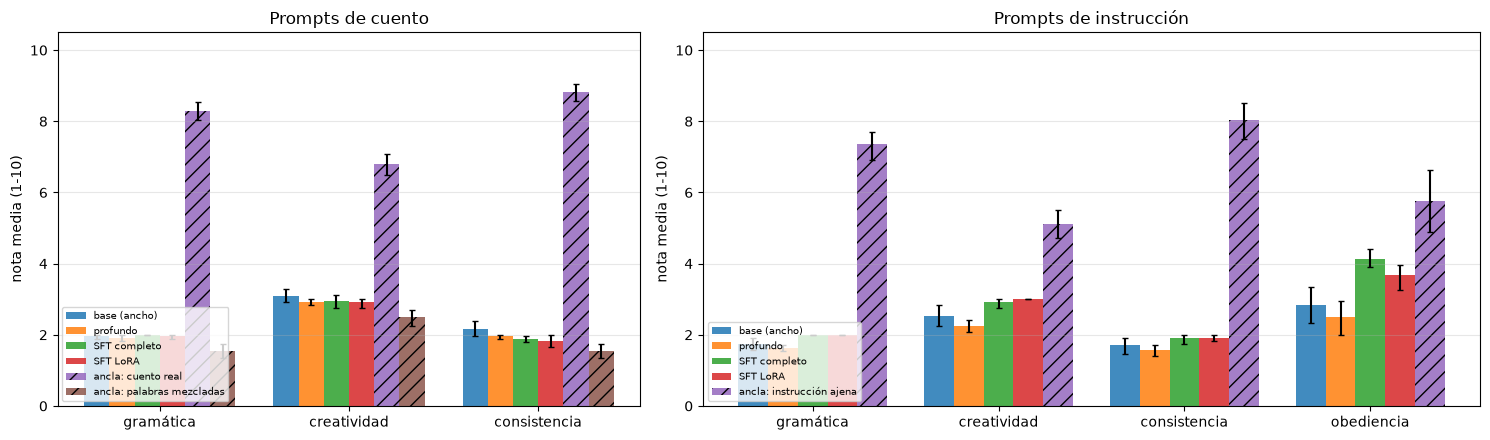

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(15, 4.5), gridspec_kw={"width_ratios": [3, 4]})
for ax, (kind, crits) in zip(axes, (("cuento", list(CRITERIA)[:3]), ("instrucción", list(CRITERIA)))):
    sub = judged[judged["tipo"] == kind]
    sources = [s for s in SOURCES if s in set(sub["fuente"])]
    width = 0.8 / len(sources)
    for k, source in enumerate(sources):
        g = sub[sub["fuente"] == source]
        stats = [bootstrap_ci(g, c) for c in crits]
        means = [s[0] for s in stats]
        err = [[m - s[1] for m, s in zip(means, stats)], [s[2] - m for m, s in zip(means, stats)]]
        hatch = "//" if source.startswith("ancla") else None
        ax.bar(np.arange(len(crits)) + k * width, means, width, yerr=err, capsize=2, label=source, hatch=hatch, alpha=0.85)
    ax.set_xticks(np.arange(len(crits)) + 0.4 - width / 2, crits)
    ax.set(ylim=(0, 10.5), ylabel="nota media (1-10)", title=f"Prompts de {kind}")
    ax.grid(axis="y", alpha=0.3)
    ax.legend(fontsize=7, loc="lower left")
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "notas.png", dpi=110)
plt.show()

## Juez contra perplejidad

Dos lecturas:

1. **Por modelo:** ¿el orden que da la perplejidad (menor es mejor) es el mismo que da el juez? Con 2-4
   modelos no hay estadística que valga; se lee el orden y el tamaño de las diferencias contra sus IC.
2. **Por texto:** correlación de Spearman entre la NLL de referencia de cada texto y cada nota del juez,
   sobre todas las generaciones de los modelos (sin anclas) y, aparte, incluyendo anclas. Si la NLL mide
   "suena a TinyStories", debería correlacionar negativo con gramática; con creatividad no hay por qué.

Se suman, si están, los números de la Etapa 2 (prompts de recuerdo y consistencia) y la Etapa 4 (uso de
palabras, pérdida en Instruct).

In [14]:
story_scores = scores.xs("cuento", level="tipo")
model_view = perplexity.join(story_scores[list(CRITERIA)[:3]], how="left")
model_view = model_view.join(scores.xs("instrucción", level="tipo")[["obediencia", "uso de palabras"]], how="left")
model_view["rango ppl"] = model_view["val ppl"].rank()
model_view["rango juez (gram+cons)"] = (-(model_view["gramática"] + model_view["consistencia"])).rank()

stage2_path = CKPT_DIR / "stage2_ablation.csv"
if stage2_path.is_file():
    stage2 = pd.read_csv(stage2_path, index_col=0).T.rename(index={"wide": "base (ancho)", "deep": "profundo"})
    keep = [c for c in stage2.columns if c.startswith(("recuerdo", "consistencia"))]
    model_view = model_view.join(stage2[keep].astype(float).add_prefix("Etapa 2 · "), how="left")
else:
    print(f"aviso: no está {stage2_path.name}; la comparación con la Etapa 2 queda sin sus prompts de prueba.")

stage4_path = CKPT_DIR / "stage4" / "comparacion_lora.csv"
if stage4_path.is_file():
    stage4 = pd.read_csv(stage4_path, index_col=0).drop(columns=["LoRA / completo"], errors="ignore").T
    stage4 = stage4.rename(index={"base": "base (ancho)", "completo": "SFT completo", "lora": "SFT LoRA"})
    model_view = model_view.join(stage4[["pérdida Instruct val"]].astype(float).add_prefix("Etapa 4 · "), how="left")

model_view.to_csv(OUTPUT_DIR / "juez_vs_perplejidad.csv")
with pd.option_context("display.width", 250, "display.max_columns", 30):
    print(model_view.T.to_string(float_format="{:.3f}".format))

                                        base (ancho)  profundo  SFT completo  SFT LoRA
val loss (TinyStories liso)                    2.334     2.359         2.574     2.544
val ppl                                       10.316    10.584        13.113    12.731
gramática                                      1.958     1.917         2.000     1.958
creatividad                                    3.083     2.917         2.958     2.917
consistencia                                   2.167     1.958         1.875     1.833
obediencia                                     2.833     2.500         4.125     3.667
uso de palabras                                0.181     0.208         0.556     0.333
rango ppl                                      1.000     2.000         4.000     3.000
rango juez (gram+cons)                         1.000     2.500         2.500     4.000
Etapa 2 · recuerdo: aciertos greedy            0.200     0.200           NaN       NaN
Etapa 2 · recuerdo: P(respuesta) media     

Spearman entre NLL de referencia por texto y nota del juez (negativo = coinciden):
              modelos  modelos + anclas
gramática       -0.35             -0.49
creatividad     -0.37             -0.49
consistencia    -0.44             -0.52
obediencia      -0.60             -0.55


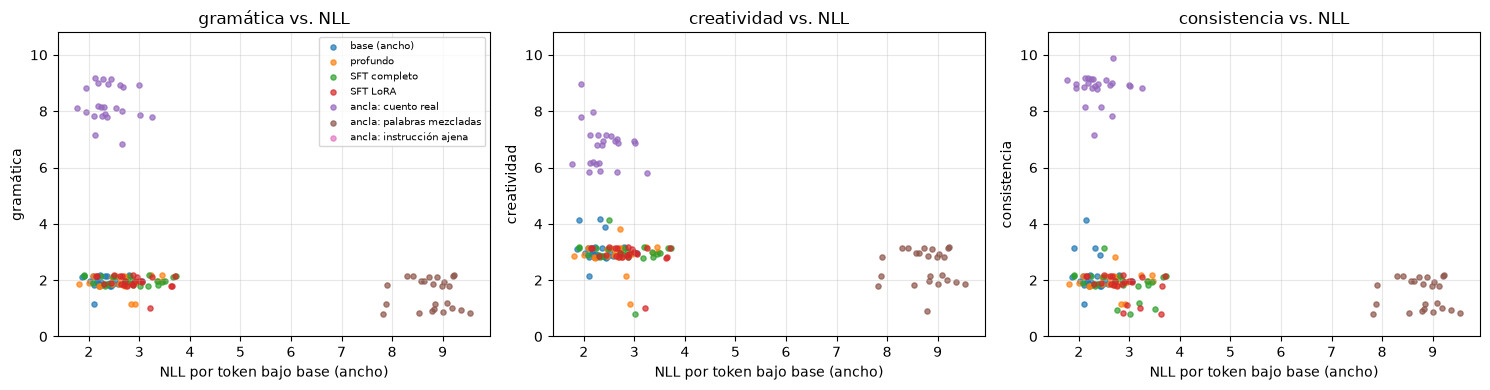

In [15]:
model_rows = judged[~judged["fuente"].str.startswith("ancla")]
corr = pd.DataFrame(
    {
        label: {crit: df[["NLL (ref)", crit]].dropna().corr(method="spearman").iloc[0, 1] for crit in CRITERIA}
        for label, df in (("modelos", model_rows), ("modelos + anclas", judged))
    }
)
corr.to_csv(OUTPUT_DIR / "correlacion_nll_juez.csv")
print("Spearman entre NLL de referencia por texto y nota del juez (negativo = coinciden):")
print(corr.to_string(float_format="{:.2f}".format))

fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharex=True)
for ax, crit in zip(axes, list(CRITERIA)[:3]):
    for source in SOURCES:
        g = judged[(judged["fuente"] == source) & (judged["tipo"] == "cuento")]
        jitter = np.random.default_rng(SEED).uniform(-0.2, 0.2, len(g))
        ax.scatter(g["NLL (ref)"], g[crit] + jitter, s=14, alpha=0.7, label=source)
    ax.set(xlabel=f"NLL por token bajo {REFERENCE}", ylabel=crit, ylim=(0, 10.8), title=f"{crit} vs. NLL")
    ax.grid(alpha=0.3)
axes[0].legend(fontsize=7)
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "juez_vs_nll.png", dpi=110)
plt.show()

### Obediencia del juez contra la cuenta automática de la Etapa 4

La Etapa 4 mide "usa las palabras" con una regex. El juez mide lo mismo leyendo. Si no correlacionan, o el
juez no está mirando la instrucción, o la regex se pierde algo (por ejemplo, una palabra usada con otro
sentido). Leer un par de casos donde discrepan.

In [16]:
instr = judged[(judged["tipo"] == "instrucción") & judged["obediencia"].notna()]
print(f"Spearman obediencia del juez vs. uso de palabras: {instr[['obediencia', 'uso de palabras']].corr(method='spearman').iloc[0, 1]:.2f}")
disagree = instr.assign(gap=(instr["obediencia"] / 10 - instr["uso de palabras"]).abs()).sort_values("gap", ascending=False)
for _, row in disagree.head(3).iterrows():
    print("-" * 100)
    print(f"{row['fuente']} · uso de palabras {row['uso de palabras']:.2f} · obediencia del juez {row['obediencia']:.0f}")
    print(row["texto"][:400])

with open(OUTPUT_DIR / "metadata.json", "w", encoding="utf-8") as f:
    json.dump(
        {
            "smoke_test": SMOKE_TEST,
            "juez": JUDGE_MODEL if JUDGE_IS_REAL else "falso (smoke)",
            "modelos": {name: str(path) for name, path in MODEL_PATHS.items() if path.is_file()},
            "referencia_nll": REFERENCE,
            "n_samples": N_SAMPLES,
            "story_prompts": STORY_PROMPTS,
            "word_prompts": WORD_PROMPTS,
            "max_new_tokens": MAX_NEW_TOKENS,
        },
        f,
        ensure_ascii=False,
        indent=2,
    )

Spearman obediencia del juez vs. uso de palabras: 0.23
----------------------------------------------------------------------------------------------------
ancla: instrucción ajena · uso de palabras 0.00 · obediencia del juez 9
Once upon a time, a little boy and his sister were playing tag in their old house. The little boy chased his sister around the kitchen. He was so close to catching her, but when he looked ahead, he noticed something.

The little boy saw an old stove in the corner of the room. He wanted to know what it was, so he walked closer to it. Suddenly, he heard his sister calling him.

Little Boy: "What is 
----------------------------------------------------------------------------------------------------
ancla: instrucción ajena · uso de palabras 0.00 · obediencia del juez 7
Once upon a time, a bald man named Max promised a 3 year old child: "Wait till spring, then you will see something special."

The little child smiled and asked "What can I see?"

Max said: "You will

## Para el informe

Completar después de **la corrida completa**. Con el juez falso del `SMOKE_TEST` las notas son ruido.

1. **¿El juez es confiable?** Antes que nada, las anclas (`notas_por_modelo.csv`): ¿cuento real > palabras
   mezcladas en gramática y consistencia, con IC que no se pisan? ¿La instrucción ajena saca obediencia
   baja? Y `formato_juez.csv`: ¿cuántas respuestas vinieron rotas o con texto extra, aun con
   `format="json"`?
2. **¿Dónde le da la razón el juez a la perplejidad?** Comparen el orden de los modelos en
   `juez_vs_perplejidad.csv` y el signo de las correlaciones en `correlacion_nll_juez.csv`. Lo esperable:
   gramática y consistencia siguen a la perplejidad (texto más probable bajo un modelo de cuentos suele
   ser más gramatical); creatividad no tiene por qué.
3. **¿Dónde se le va para otro lado, y qué dice eso de la perplejidad?** Casos típicos a buscar:
   - el SFT empeora la perplejidad en texto liso pero el juez le pone igual o mejor nota (la perplejidad
     penaliza el cambio de formato, no la calidad del cuento);
   - un texto repetitivo tiene NLL bajísima (cada repetición es predecible) y el juez lo castiga en
     creatividad: la perplejidad premia lo predecible;
   - ancho vs. profundo: ¿el juez separa lo que la perplejidad casi no separa, o al revés? Crucen con los
     prompts de recuerdo y consistencia de la Etapa 2.
4. **Obediencia:** ¿el SFT sube la obediencia sobre el base en los mismos prompts? ¿Coincide con el uso de
   palabras de la Etapa 4? Si el juez y la regex discrepan, ¿quién tiene razón en los casos leídos?